In [1]:
!pip install xgboost

In [2]:
# Imports 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

In [3]:
df = pd.read_csv("D:\portfolio_project\Project 1 - End-to-End E-Commerce Data Analytics & Dashboarding Solution\Data\Cleaned_Salesdata.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Unnamed: 0           100000 non-null  int64  
 1   OrderID              100000 non-null  object 
 2   OrderDate            100000 non-null  object 
 3   CustomerID           100000 non-null  object 
 4   CustomerName         100000 non-null  object 
 5   ProductID            100000 non-null  object 
 6   ProductName          100000 non-null  object 
 7   Category             100000 non-null  object 
 8   Brand                100000 non-null  object 
 9   Quantity             100000 non-null  int64  
 10  UnitPrice            100000 non-null  float64
 11  Discount             100000 non-null  float64
 12  Tax                  100000 non-null  float64
 13  ShippingCost         100000 non-null  float64
 14  TotalAmount          100000 non-null  float64
 15  PaymentMethod     

In [5]:
print("\n Unique values:")
df.nunique()


 Unique values:


Unnamed: 0             100000
OrderID                100000
OrderDate                1825
CustomerID              43233
CustomerName              200
ProductID                  50
ProductName                50
Category                    6
Brand                      10
Quantity                    5
UnitPrice               48433
Discount                    7
Tax                     23002
ShippingCost             1501
TotalAmount             79208
PaymentMethod               6
OrderStatus                 5
City                       20
State                      13
Country                     5
SellerID                 1999
OrderYear                   5
OrderMonth                 12
OrderMonthName             12
OrderQuarter                4
OrderWeekday                7
OrderDay                   31
OrderStatusCategory         3
dtype: int64

In [6]:
'''Exploratory Data Analysis - Visualizations'''

'Exploratory Data Analysis - Visualizations'

Country
United States     70058
India             15051
Canada             5818
United Kingdom     4943
Australia          4130
Name: count, dtype: int64


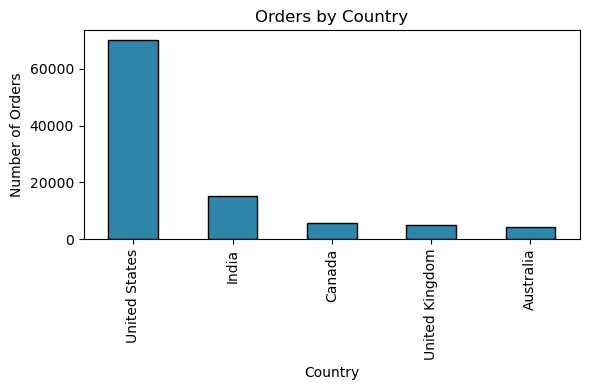

In [7]:
#Orders by Country
country_counts = df['Country'].value_counts()

print(country_counts)

plt.figure(figsize=(6,4))
country_counts.plot(kind='bar' , color='#2E86AB', edgecolor='black')
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.title('Orders by Country')
plt.tight_layout()
plt.show()

Category
Electronics          16853
Sports & Outdoors    16804
Books                16752
Home & Kitchen       16610
Toys & Games         16542
Clothing             16439
Name: count, dtype: int64


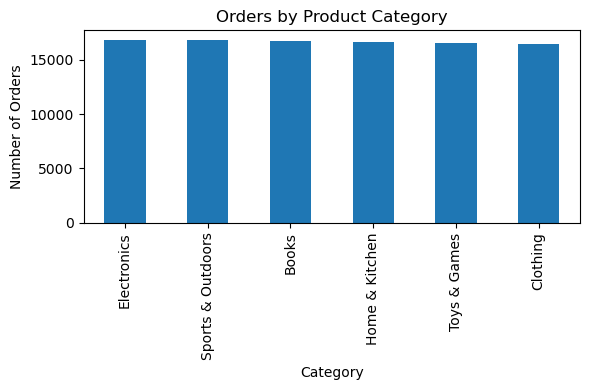

In [8]:
#Orders by Category
cat_counts = df['Category'].value_counts()

print(cat_counts)

plt.figure(figsize=(6,4))
cat_counts.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.title('Orders by Product Category')
plt.tight_layout()
plt.show()

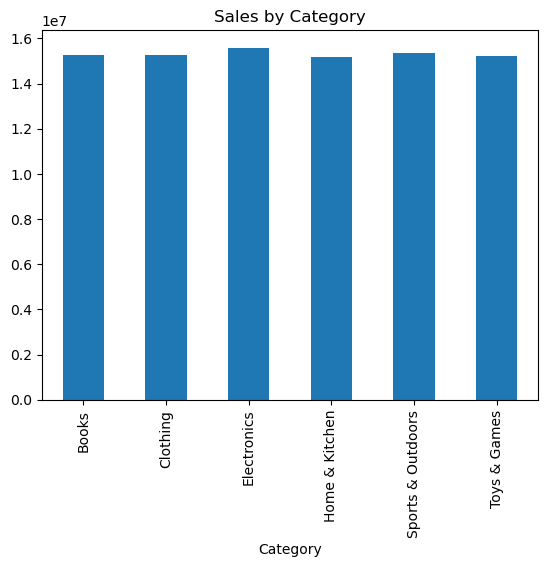

In [9]:
category_sales = df.groupby('Category')['TotalAmount'].sum()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

PaymentMethod
Credit Card         35038
Debit Card          20024
UPI                 15066
Amazon Pay          15017
Net Banking          9927
Cash on Delivery     4928
Name: count, dtype: int64


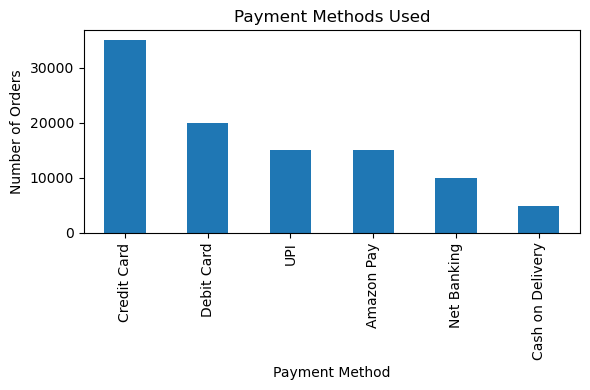

In [10]:
#Payment method usage
pay_counts = df['PaymentMethod'].value_counts()

print(pay_counts)

plt.figure(figsize=(6,4))
pay_counts.plot(kind='bar')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.title('Payment Methods Used')
plt.tight_layout()
plt.show()

In [11]:
#Total revenue
total_revenue = df['TotalAmount'].sum()
print("Total Revenue :", total_revenue)

Total Revenue : 91825647.92


Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Name: TotalAmount, dtype: float64


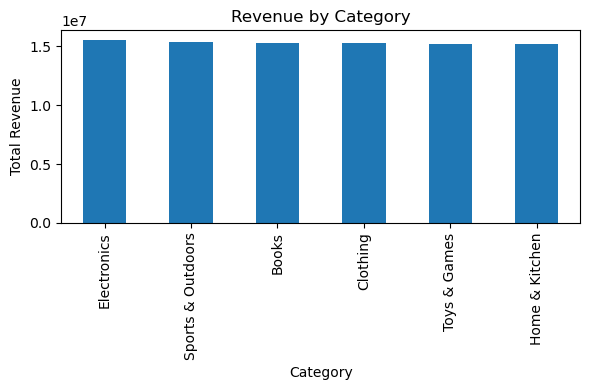

In [12]:
#Revenue by Category
rev_by_cat = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
print(rev_by_cat)

plt.figure(figsize=(6,4))
rev_by_cat.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.title('Revenue by Category')
plt.tight_layout()
plt.show()

Country
United States     64310048.50
India             13875839.12
Canada             5323757.00
United Kingdom     4526896.86
Australia          3789106.44
Name: TotalAmount, dtype: float64


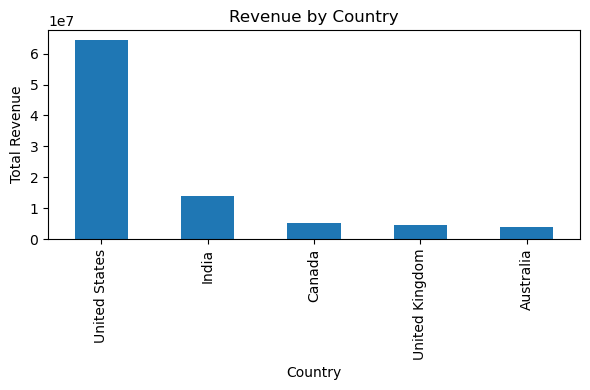

In [13]:
#Revenue by Country
rev_by_country = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)
print(rev_by_country)

plt.figure(figsize=(6,4))
rev_by_country.plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.title('Revenue by Country')
plt.tight_layout()
plt.show()

YearMonth
2020-01    1730
2020-02    1490
2020-03    1685
2020-04    1692
2020-05    1672
2020-06    1633
2020-07    1687
2020-08    1783
2020-09    1679
2020-10    1647
2020-11    1639
2020-12    1729
2021-01    1764
2021-02    1516
2021-03    1620
2021-04    1594
2021-05    1716
2021-06    1668
2021-07    1718
2021-08    1704
2021-09    1674
2021-10    1672
2021-11    1587
2021-12    1657
2022-01    1744
2022-02    1510
2022-03    1710
2022-04    1636
2022-05    1709
2022-06    1690
2022-07    1689
2022-08    1717
2022-09    1645
2022-10    1633
2022-11    1642
2022-12    1753
2023-01    1721
2023-02    1540
2023-03    1683
2023-04    1641
2023-05    1709
2023-06    1650
2023-07    1712
2023-08    1733
2023-09    1665
2023-10    1660
2023-11    1656
2023-12    1726
2024-01    1679
2024-02    1562
2024-03    1740
2024-04    1647
2024-05    1753
2024-06    1671
2024-07    1631
2024-08    1731
2024-09    1613
2024-10    1642
2024-11    1624
2024-12    1577
Freq: M, Name: OrderID, dtype:

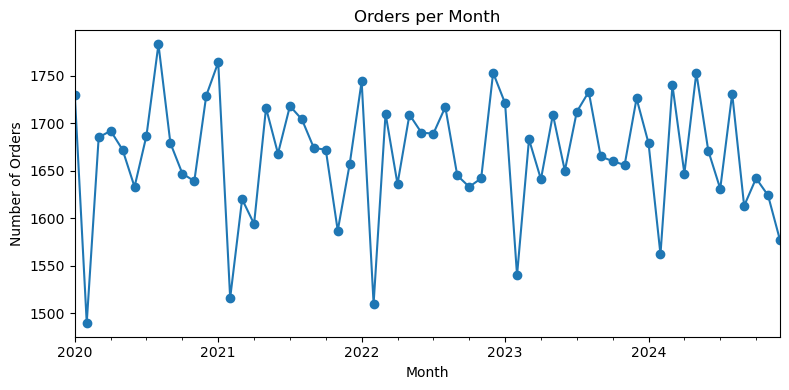

In [14]:
#Orders per month
# Convert OrderDate to datetime format first
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

df['YearMonth'] = df['OrderDate'].dt.to_period('M')

orders_per_month = df.groupby('YearMonth')['OrderID'].nunique()

print(orders_per_month)

plt.figure(figsize=(8,4))
orders_per_month.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Orders per Month')
plt.tight_layout()
plt.show()

YearMonth
2020-01    1637069.40
2020-02    1339388.21
2020-03    1587125.66
2020-04    1588347.29
2020-05    1533834.17
2020-06    1500269.29
2020-07    1552981.94
2020-08    1640874.93
2020-09    1554682.21
2020-10    1515403.62
2020-11    1502232.24
2020-12    1577655.06
2021-01    1575253.23
2021-02    1425365.99
2021-03    1484165.89
2021-04    1470885.02
2021-05    1571842.25
2021-06    1593398.08
2021-07    1596668.40
2021-08    1545324.30
2021-09    1534912.30
2021-10    1511118.44
2021-11    1419480.77
2021-12    1520160.14
2022-01    1609759.87
2022-02    1369866.29
2022-03    1589809.35
2022-04    1515497.24
2022-05    1527845.26
2022-06    1533829.81
2022-07    1556516.29
2022-08    1541701.50
2022-09    1457859.60
2022-10    1534349.51
2022-11    1525937.46
2022-12    1604276.23
2023-01    1567772.07
2023-02    1384957.09
2023-03    1557146.56
2023-04    1560322.12
2023-05    1588151.65
2023-06    1485367.09
2023-07    1562298.78
2023-08    1585424.79
2023-09    1543306.82


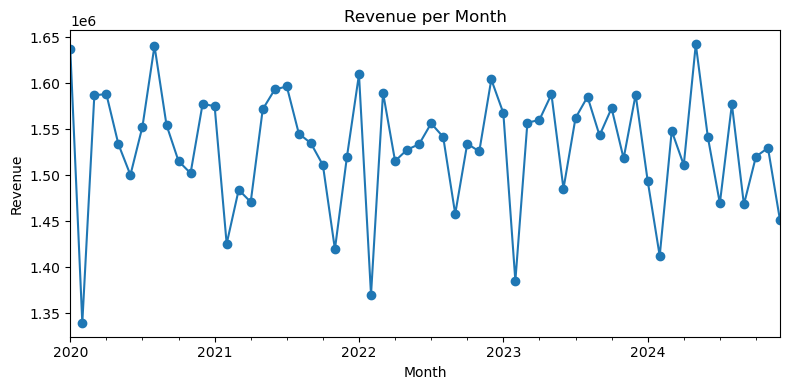

In [15]:
#Revenue per month
rev_per_month = df.groupby('YearMonth')['TotalAmount'].sum()

print(rev_per_month)

plt.figure(figsize=(8,4))
rev_per_month.plot(kind='line', marker='o')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Revenue per Month')
plt.tight_layout()
plt.show()

ProductName
Memory Card 128GB      1935138.40
LED Desk Lamp          1921948.41
Mechanical Keyboard    1906963.54
Electric Kettle        1905751.79
Smartwatch             1901275.59
Dress Shirt            1896765.36
Water Bottle           1895467.95
Gaming Mouse           1895103.98
Kids Toy Car           1891082.43
Jeans                  1882591.82
Name: TotalAmount, dtype: float64


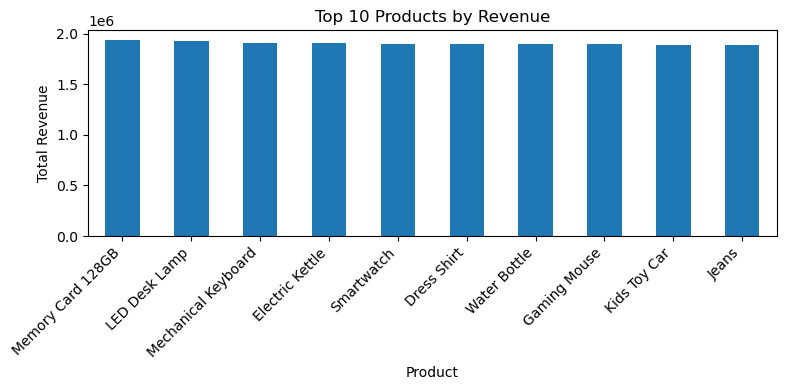

In [16]:
#Top 10 products by revenue
prod_rev = df.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)

print(prod_rev)

plt.figure(figsize=(8,4))
prod_rev.plot(kind='bar')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.title('Top 10 Products by Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
#Top 10 sellers by revenue
seller_rev = df.groupby('SellerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(seller_rev)

SellerID
SELL00806    71283.67
SELL00440    71062.59
SELL01225    70785.92
SELL00709    70491.92
SELL00221    70446.50
SELL01122    69469.40
SELL00994    69400.06
SELL00536    69248.00
SELL00371    69118.88
SELL00812    68591.86
Name: TotalAmount, dtype: float64


CustomerName
Pooja Kapoor    547832.64
Vihaan Singh    526675.89
Pooja Singh     516451.45
Kabir Joshi     515361.68
Aditya Gupta    515005.09
Mohit Singh     513513.19
Sunita Mehta    511642.91
Aman Reddy      511236.91
Karan Singh     510900.60
Simran Singh    509337.35
Name: TotalAmount, dtype: float64


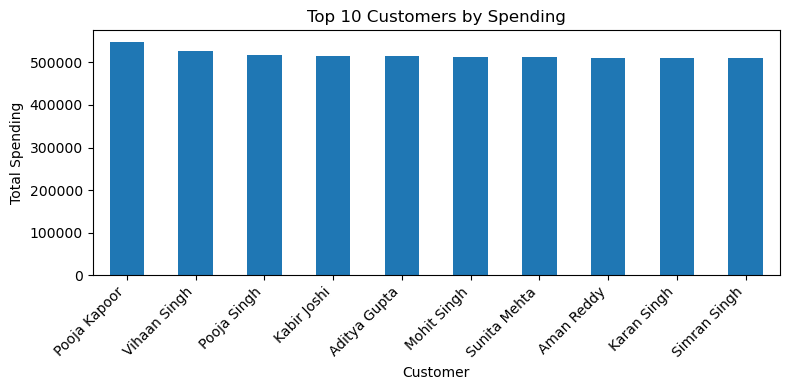

In [18]:
#Top 10 customers by spending
cust_rev = df.groupby('CustomerName')['TotalAmount'].sum().sort_values(ascending=False).head(10)
print(cust_rev)

plt.figure(figsize=(8,4))
cust_rev.plot(kind='bar')
plt.xlabel('Customer')
plt.ylabel('Total Spending')
plt.title('Top 10 Customers by Spending')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
# Select Numerical and Categorical Columns

num_cols = df.select_dtypes(include=['number']).columns.to_list()
cat_cols = df.select_dtypes(include=['object']).drop('ProductName', axis=1).columns.to_list()

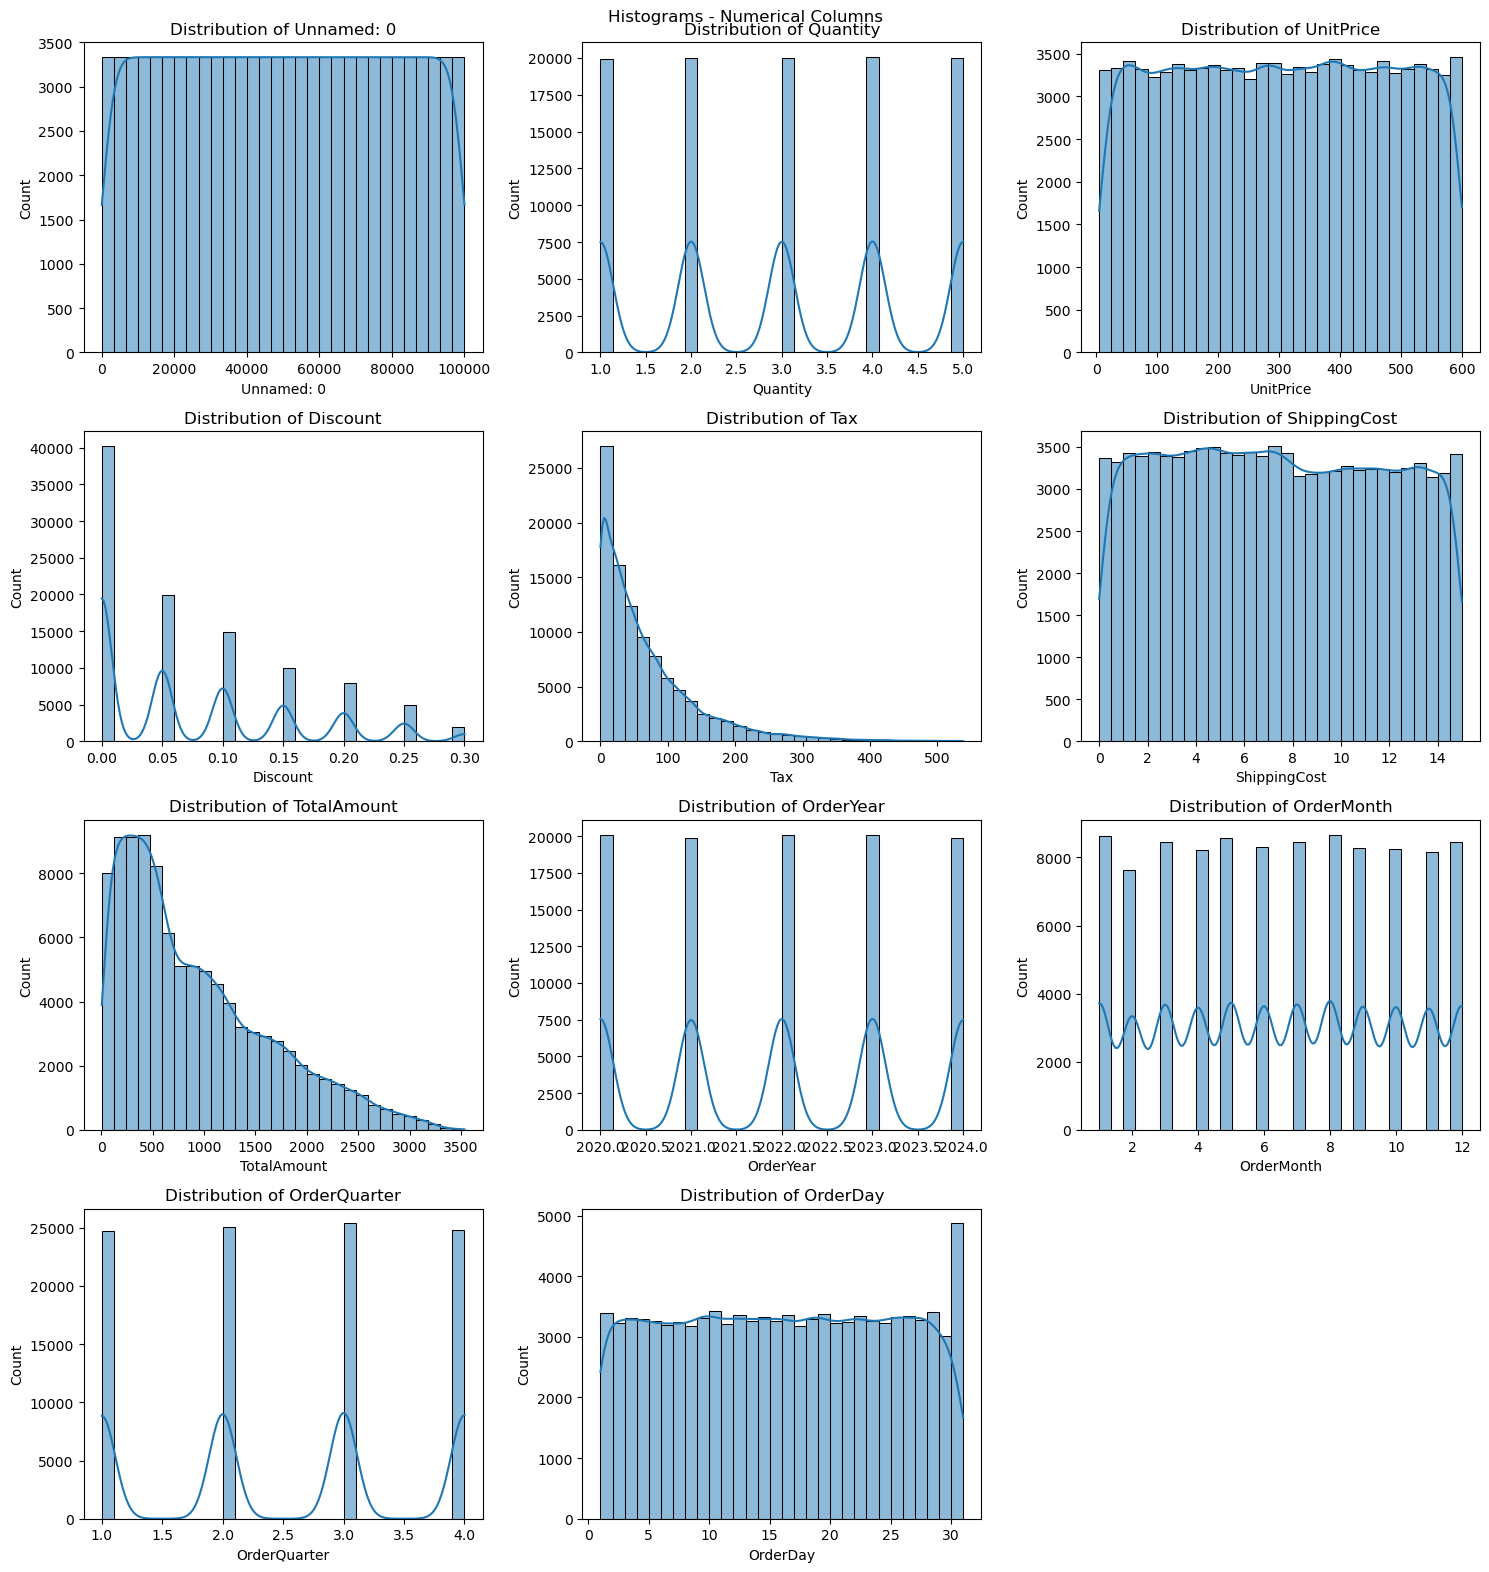

In [20]:
#Distribution Analysis (Histogram)
# Make Histograms for All Numerical Columns

columns = 3
rows = (len(num_cols) + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(5*columns, 4*rows))
axes = axes.flatten()

plt.suptitle('Histograms - Numerical Columns')

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

for ax in axes[len(num_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
# Observe Outlier Rows

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).any(axis=1)
outlier_mask.sum()

np.int64(7481)

In [22]:
# Observe Skewness and Kurtosis

skew = df[num_cols].skew()
kurt = df[num_cols].kurtosis()

pd.DataFrame({'Skewness': skew, 'Kurtosis': kurt})

,Skewness,Kurtosis
Unnamed: 0,0.000000,-1.200000
Quantity,-0.001435,-1.299197
UnitPrice,-0.003291,-1.198888
Discount,0.952539,-0.101604
Tax,1.934145,4.876961
ShippingCost,0.037686,-1.193711
TotalAmount,0.945229,0.177891
OrderYear,-0.000877,-1.298017
OrderMonth,-0.006926,-1.200233
OrderQuarter,-0.006166,-1.350443


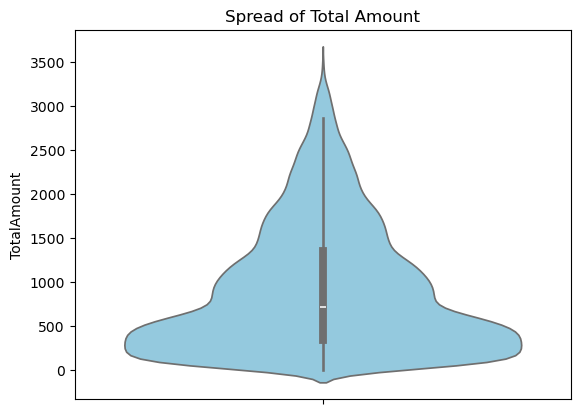

In [23]:
# Analyze Total Amount More Before Predictions

plt.title('Spread of Total Amount')

sns.violinplot(df['TotalAmount'], color='skyblue')

plt.show()

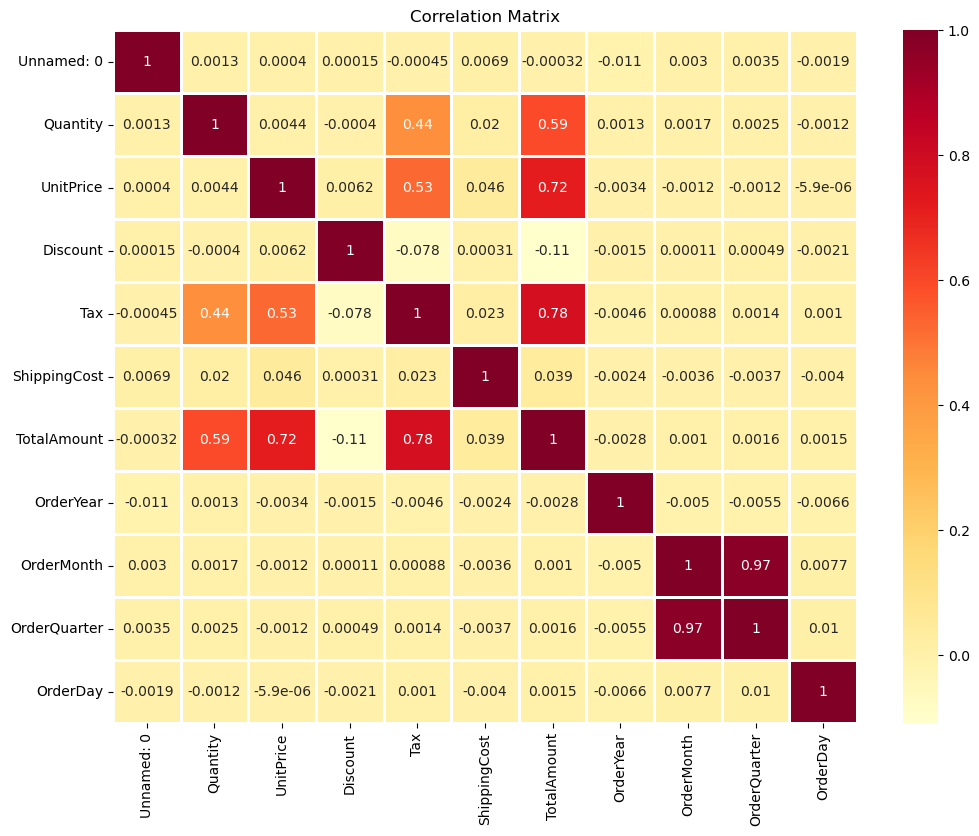

In [24]:
# Make a Correlation Matrix to Examine Relationships to Guide Scatters

plt.figure(figsize=(12,9))

sns.heatmap(df[num_cols].corr(), annot=True, linewidth=0.9, cmap='YlOrRd')

plt.title('Correlation Matrix')

plt.show()

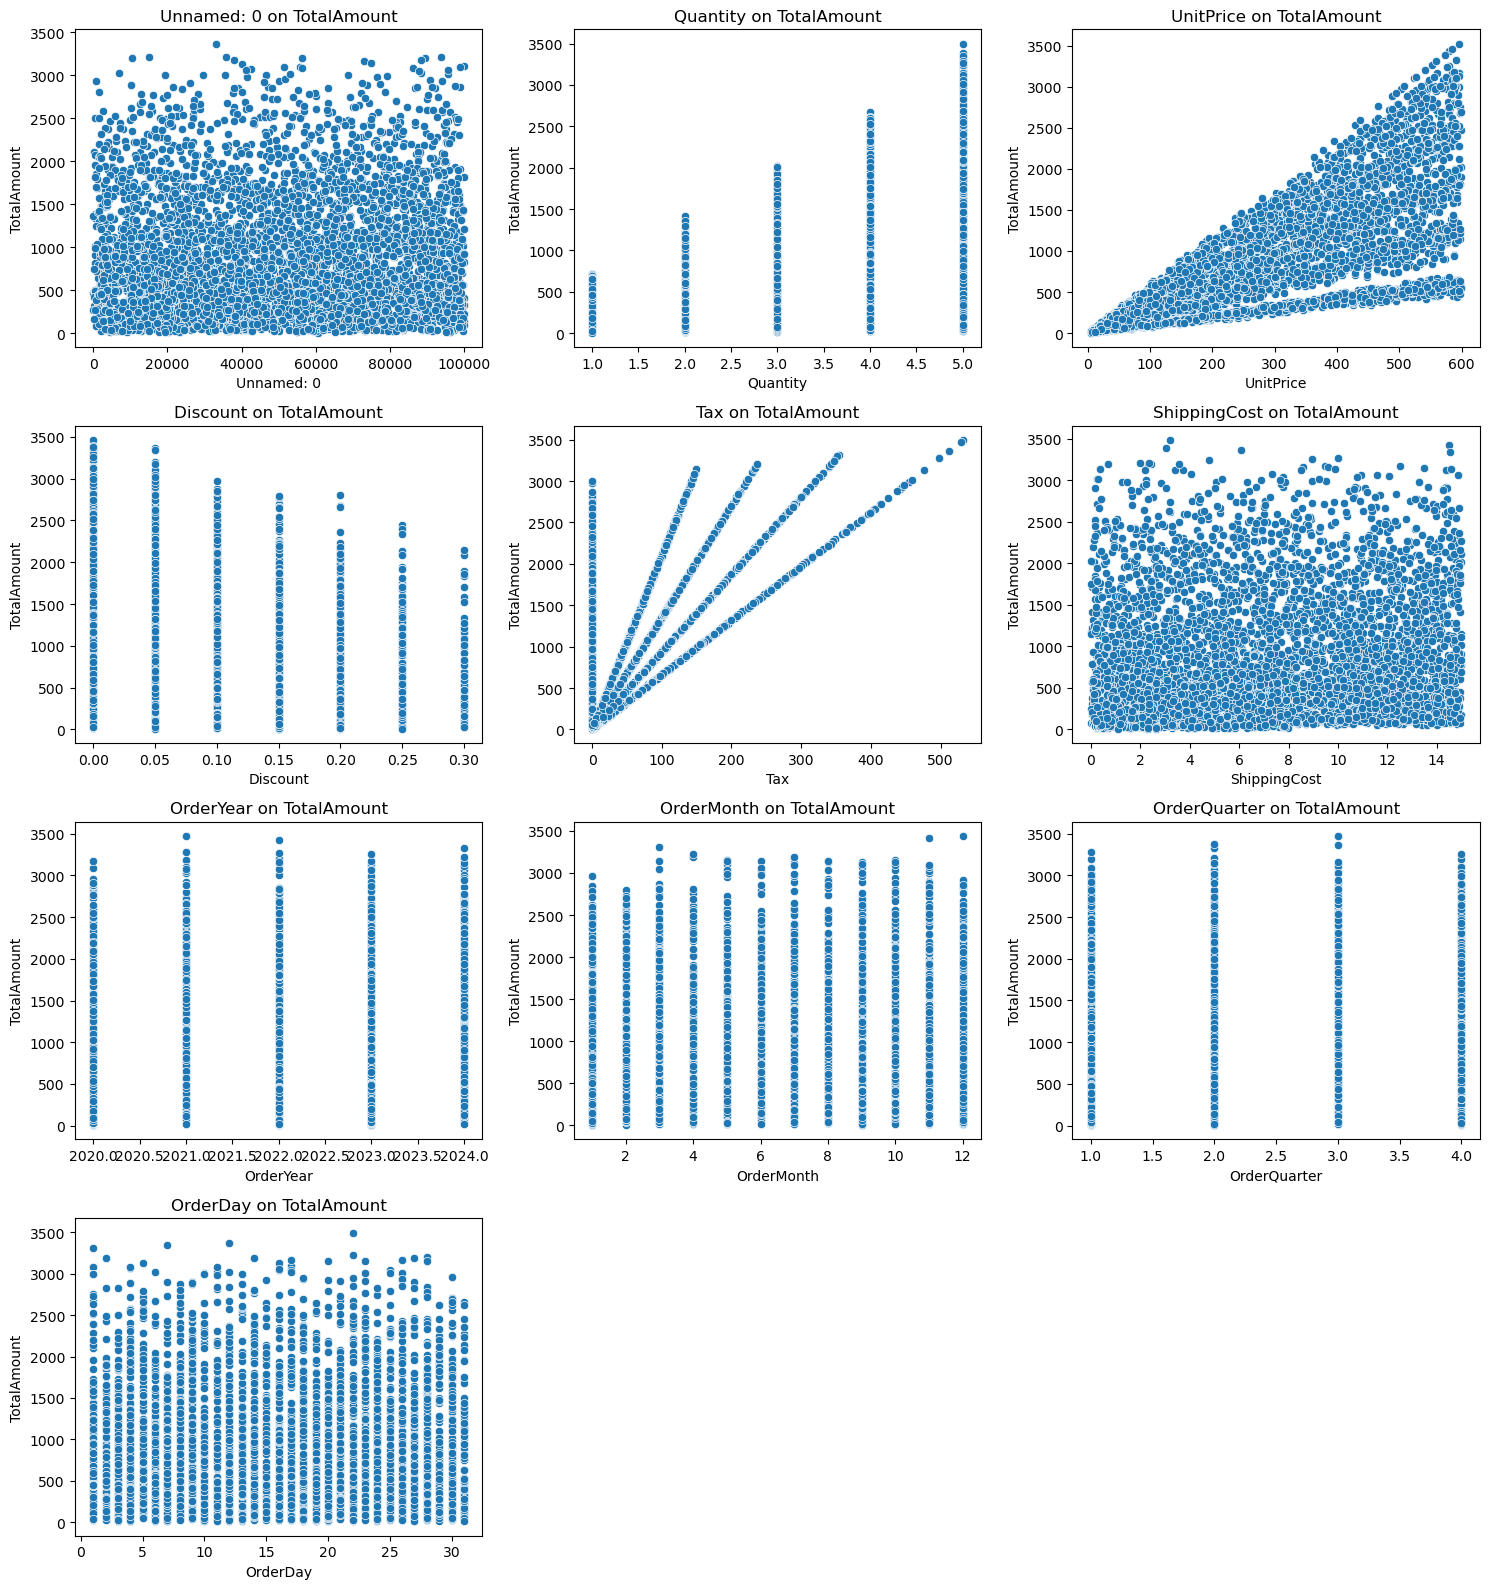

In [25]:
# Now Make Scatter Plots

x_cols = [col for col in num_cols if col != 'TotalAmount']
y = 'TotalAmount'

columns = 3
rows = (len(x_cols) + columns - 1) // columns

fig, axes = plt.subplots(rows, columns, figsize=(5*columns, 4*rows))
axes = axes.flatten()

for i, x in enumerate(x_cols):
    sns.scatterplot(data=df.sample(4500), x=x, y=y, ax=axes[i])
    axes[i].set_title(f'{x} on {y}')

for ax in axes[len(x_cols): ]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
# Make Model

X = df.drop('TotalAmount', axis=1)
y = df['TotalAmount']

num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    objective="reg:squarederror",
    random_state=42
)

pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('xgb', model)
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.25, 
    random_state=42
)

pipeline.fit(X_train, y_train)

prediction = pipeline.predict(X_val)

r2_score(y_val, prediction), mean_absolute_error(y_val, prediction)

(0.9991443821900272, 15.281553930208299)